In [1]:
import functions
import os
from data import data, path_map, masks, path_masks, color_corrections
import healpy as hp
import numpy as np
from astropy.io import fits

In [46]:
# Reload functions module to get latest changes
import importlib
importlib.reload(functions)

<module 'functions' from '/home/pablo/Desktop/master/tfm/python/1-methodology_tests/functions.py'>

In [2]:
# Default configuration
nside = 512
n_sim = 100
path_save = path_map + 'PYSM/'

quijote_bands = ['11', '13', '17', '19']
wmap_bands = ['23', '33', '41', '61', '94']
planck_bands = ['30', '44', '70', '100', '143', '217', '353']


band_list = quijote_bands + wmap_bands + planck_bands

name_suffix = '_full_bin_20-199'

# Differential Assemblies (DAs) per frequency band
BANDS = {
    'K': ['K1'],
    'Ka': ['Ka1'],
    'Q': ['Q1', 'Q2'],
    'V': ['V1', 'V2'],
    'W': ['W1', 'W2', 'W3', 'W4'],
}

lmax = 2 * nside - 1
dl = 10

mask_select = masks['QUIJOTE_galcut']['galcut10']
mask_name = mask_select['name']
use_simulated_maps = False
use_white_noise = False
use_noise = False # Use noise simulations instead of the HMDM for QUIJOTE autos
out_path = '/home/pablo/Desktop/master/tfm/spectra/'
path_spectra = os.path.join(out_path, f'power_spectra_{mask_name}{name_suffix}.fits')
path_hmdm_spectra = os.path.join(out_path, f'power_spectra_{mask_name}_hmdm{name_suffix}.fits')
path_avg_std_skyplusnoise = os.path.join(out_path, f'spectra_avg_std_{mask_name}_avg_std{n_sim}_skyplusnoise{name_suffix}.fits')
path_avg_std_noise = os.path.join(out_path, f'spectra_avg_std_{mask_name}_avg_std{n_sim}_noise{name_suffix}.fits')
# Store per-simulation spectra compressed on disk (Astropy supports .fits.gz transparently)
path_full_skyplusnoise = os.path.join(out_path, f'spectra_full_{mask_name}_{n_sim}_skyplusnoise{name_suffix}.fits.gz')
path_full_noise = os.path.join(out_path, f'spectra_full_{mask_name}_{n_sim}_noise{name_suffix}.fits.gz')
path_corrected_spectra = os.path.join(out_path, f'corrected_power_spectra_{mask_name}{name_suffix}.fits')


#Create binning scheme
ell_1 = [20, 40, 60, 80, 100, 120, 140, 160, 180]
ell_2 = [39, 59, 79, 99, 119, 139, 159, 179, 199]

binning_params = {
    'type': 'edges',  #'linear' or 'edges'
    'lmax': lmax,
    'dl': dl,
    # For edges
    'ell1': ell_1,
    'ell2': ell_2
}


In [ ]:
mask = hp.read_map(mask_select['path'])

$\textbf{Part 1: Simulated maps using PySM}$

In [ ]:

# Generate maps
functions.generate_sky_maps(nside, path_save, experiment_select='QUIJOTE', band_select=quijote_bands)
functions.generate_sky_maps(nside, path_save, experiment_select='WMAP', band_select=wmap_bands)
functions.generate_sky_maps(nside, path_save, experiment_select='Planck', band_select=planck_bands)

$\textbf{Part 2: Simulated white noise maps}$

In [ ]:
functions.white_noise_maps(data, nside, experiment_select='QUIJOTE', band_select=quijote_bands, n_sim=n_sim, path_map=path_map)
functions.white_noise_maps(data, nside, experiment_select='WMAP', band_select=wmap_bands, n_sim=n_sim, path_map=path_map)
functions.white_noise_maps(data, nside, experiment_select='Planck', band_select=planck_bands, n_sim=n_sim, path_map=path_map)

$\textbf{Part 3: Build HMDM}$

In [ ]:
base_dir = os.path.dirname(data['WMAP']['23']['hmdm'])
save_path = os.path.dirname(data['WMAP']['23']['hmdm'])

combined_1to4 = functions.coadd_year_range(base_dir=base_dir, year_1=1, year_2=4, save=True, save_path=save_path)
combined_5to9 = functions.coadd_year_range(base_dir=base_dir, year_1=5, year_2=9, save=True, save_path=save_path)

In [ ]:
functions.make_hmdm(data, band_list, save=True)

$\textbf{Part 4: Build beams WMAP}$

In [ ]:
beam_path = os.path.dirname(data['WMAP']['23']['beam'])
save_path = os.path.dirname(data['WMAP']['23']['beam'])

functions.generate_band_beams(
    BANDS,
    beam_path=beam_path,
    save_path=save_path,
    data_dict=data,
    use_qu=True,     # use noise_QU for polarization beams
    mask_path=None
)

$\textbf{Part 5: Compute power spactra}$

In [ ]:
# 1. Prepare binning scheme
b = functions.create_binning(binning_params)

# 2. Precompute workspaces
workspaces = functions.prepare_workspaces(mask, b, nside, lmax=lmax, purify_e=True, purify_b=True)

In [ ]:
# 3. Compute all spectra
spectra_matrix = functions.compute_all_power_spectra(
    data, band_list, mask, b,
    use_simulated_maps=use_simulated_maps,
    use_white_noise=use_white_noise,
    noise_realization=1,
    only_noise=False,
    workspaces=workspaces,
    lmax=lmax
)

# 4. Save spectra matrix into a FITS file
functions.save_spectra_to_fits(spectra_matrix, band_list, out_file=path_spectra)

In [ ]:
# 5. Compute HMDM spectra
hmdm_spectra_matrix = functions.compute_hmdm_power_spectra(
    data, band_list, mask, b, workspaces=workspaces, lmax=lmax, use_noise=use_noise
)

# 6. Save spectra matrix into a FITS file
functions.save_spectra_to_fits(hmdm_spectra_matrix, band_list, out_file=path_hmdm_spectra)

In [ ]:
# 7. Read spectra matrix from FITS
spectra_dict = functions.read_spectra_from_fits(path_spectra, band_list)

In [ ]:
# 8. Compute mean and std over noise realizations (sky + noise)
avg_std_skyplusnoise_dict = functions.average_and_std_spectra(
    data, spectra_dict, band_list, mask, b,
    use_white_noise=use_white_noise,
    n_sim=n_sim, 
    only_noise=False,
    workspaces=workspaces,
    lmax=lmax,
    capture_sims=True  # capture per-simulation arrays for full FITS
)


# 9. Compute mean and std for noise-only maps
avg_std_noise_dict = functions.average_and_std_spectra(
    data, spectra_dict, band_list, mask, b,
    use_white_noise=use_white_noise,
    n_sim=n_sim,
    only_noise=True,
    workspaces=workspaces,
    lmax=lmax,
    capture_sims=True  # capture per-simulation arrays for full FITS
)

In [ ]:
functions.save_sims_to_fits(
    avg_std_skyplusnoise_dict,
    band_list,
    out_file=path_full_skyplusnoise,
    use_white_noise=use_white_noise,
    sims_npz=None,
    avg_std_out_file=path_avg_std_skyplusnoise,
    dtype='float32',
    sims_layout='vector',
    hdu_grouping='by_bandpair',
)

functions.save_sims_to_fits(
    avg_std_noise_dict,
    band_list,
    out_file=path_full_noise,
    use_white_noise=use_white_noise,
    sims_npz=None,
    avg_std_out_file=path_avg_std_noise,
    dtype='float32',
    sims_layout='vector',
    hdu_grouping='by_bandpair',
)

$\textbf{Part 6: Correct power spectra}$

In [5]:
# Path to Planck CMB spectrum (best-fit cosmology)
cmb_spectrum_file = '/home/pablo/Desktop/master/tfm/spectra/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt'

corr_spectra, out_file = functions.correct_power_spectra(
    path_spectra, path_avg_std_skyplusnoise, path_avg_std_noise,
    band_list, data, nside, 
    correct_beam=True, 
    correct_unit=True,                    # Convert to K²_RJ (Planck 2018 convention)
    correct_pixel=True, 
    save=True, 
    path_out_file=path_corrected_spectra,
    use_white_noise=use_white_noise,
    use_noise=use_noise,                  # Use mean noise sim for QUIJOTE autos when True
    path_hmdm_spectra=path_hmdm_spectra,
    subtract_cmb=True,                    # Subtract Planck CMB spectrum
    cmb_spectrum_path=cmb_spectrum_file   # Path to real Planck spectrum
)


[INFO] Loading CMB spectrum from /home/pablo/Desktop/master/tfm/spectra/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt
[INFO] Loaded CMB spectrum with format: Planck PLA
[OK] Saved corrected spectra with errors to /home/pablo/Desktop/master/tfm/spectra/corrected_power_spectra_quijote_galcut10_full_bin_20-199.fits


$\textbf{Part 8: MCMC fitting}$

In [ ]:
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

In [ ]:
# -------------------------------
# Fitting configuration (power-law with Gaussian priors and cross-only pairs)
# -------------------------------
from functions import set_gaussian_priors

# Gaussian priors:
# - beta_s ~ N(-3.1, 0.18)  synchrotron spectral index (frequency)
# - beta_d ~ N(1.55, 0.05)  dust spectral index (frequency)
# - alpha_s ~ N(-3.0, 0.30) synchrotron ell-slope (same for EE/BB)
# - alpha_d ~ N(-2.48, 0.20) dust ell-slope (average of Planck ~-2.42 EE and ~-2.54 BB)
#   Dust temperature T_d is fixed internally at 19.6 K (effectively a delta prior).

# set_gaussian_priors({
#     'beta_s': (-3.1, 0.18),
#     'beta_d': (1.55, 0.05),
#     'alpha_s': (-3.0, 0.30),
#     'alpha_d': (-2.48, 0.20),
# })

set_gaussian_priors(None)

fitting_mode = 'power-law'

# Multipole range
ell_min = 30
ell_max = 120

# Sampler configuration
nwalkers = 200
ninter = 25000
discard_fraction = 0.5

# Components to fit in the power-law model
fit_components = (
    'sync',
    'dust',
    'cross'
)

# Bands to include in the fit (auto + cross among these)
# QUIJOTE: 11, 13
# WMAP: K(23), Ka(33)
# Planck: LFI 30, HFI 100/143/217/353
quijote_fit_bands = ['11', '17']
wmap_fit_bands = ['23', '33', '41', '61', '94']
planck_fit_bands = ['30', '44', '70', '100', '143', '217', '353']

band_list_fit = quijote_fit_bands + wmap_fit_bands + planck_fit_bands

# # Build cross-only band pairs across all bands (exclude autos)
# band_pairs_cross_all = []
# for i in range(len(band_list)):
#     for j in range(i + 1, len(band_list)):
#         band_pairs_cross_all.append(f"{band_list[i]}_{band_list[j]}")

# # Use cross-only pairs
# band_pairs = band_pairs_cross_all

# Use 'all' to include both autos and crosses within band_list_fit
band_pairs = 'all'

fit_c_terms = False

# Save paths for corner plots
components_str = '_'.join(fit_components)
save_path_EE = f'/home/pablo/Desktop/master/tfm/figures/corner/corner_{mask_name}_{components_str}_EE{name_suffix}.pdf'
save_path_BB = f'/home/pablo/Desktop/master/tfm/figures/corner/corner_{mask_name}_{components_str}_BB{name_suffix}.pdf'
save_path_EE_BB = f'/home/pablo/Desktop/master/tfm/figures/corner/corner_{mask_name}_{components_str}_EE-BB{name_suffix}.pdf'


# Load corrected spectra
spectra_dict = functions.read_corrected_cls(path_corrected_spectra, band_list)

In [ ]:
# Prepare EE data and run MCMC (power-law with prior and cross-only pairs)
fit_data_EE = functions.prepare_mcmc_data(
    spectra_dict,
    band_list=band_list_fit,
    modes=['EE'],
    ell_min=ell_min,
    ell_max=ell_max,
    band_pairs=band_pairs
)

# Build Covariance for QUIJOTE correlated blocks (11-13 and 17-19)
cov_info_BB = functions.build_block_diagonal_cov_inv(
    path_sims_fits=path_full_skyplusnoise,
    fit_data=fit_data_BB,
    modes=['BB'],
    quijote_bands_11_13=['11', '13'],
    quijote_bands_17_19=['17', '19'],
    path_noise_sims=path_full_noise,
    data_dict=data,
    nside=nside
)

In [ ]:
sampler_BB, samples_full_EE, samples_free_EE, param_map_EE, chi2_reduced_EE = functions.run_mcmc(
    fit_data=fit_data_EE,
    fit_components=fit_components,
    fit_c_terms=fit_c_terms,
    nwalkers=nwalkers,
    ninter=ninter,
    discard_fraction=discard_fraction,
    verbose=True,  # Show progress bar
    fit_mode=fitting_mode,
    color_correction=True,
    joint_analysis=False, 
    cov_matrix=cov_info_EE  # Pass QUIJOTE covariance blocks
)

In [ ]:
# Plot and save the corner plot
fig_EE = functions.plot_corner(samples_free_EE, param_map_EE, save_path_EE, title=f'EE Mode')

In [ ]:
# Prepare BB data and run MCMC (power-law with prior and cross-only pairs)
fit_data_BB = functions.prepare_mcmc_data(
    spectra_dict,
    band_list=band_list_fit,
    modes=['BB'],
    ell_min=ell_min,
    ell_max=ell_max,
    band_pairs=band_pairs
)

# Build Covariance for QUIJOTE correlated blocks (11-13 and 17-19)
cov_info_BB = functions.build_block_diagonal_cov_inv(
    path_sims_fits=path_full_skyplusnoise,
    fit_data=fit_data_BB,
    modes=['BB'],
    quijote_bands_11_13=['11', '13'],
    quijote_bands_17_19=['17', '19'],
    path_noise_sims=path_full_noise,
    data_dict=data,
    nside=nside
)

# Run MCMC with the selected fitting mode
sampler_BB, samples_full_BB, samples_free_BB, param_map_BB, chi2_reduced_BB = functions.run_mcmc(
    fit_data=fit_data_BB,
    fit_components=fit_components,
    fit_c_terms=fit_c_terms,
    nwalkers=nwalkers,
    ninter=ninter,
    discard_fraction=discard_fraction,
    verbose=True,  # Show progress bar
    fit_mode=fitting_mode,
    color_correction=True,
    joint_analysis=False, 
    cov_matrix=cov_info_BB  # Pass QUIJOTE covariance blocks
)

In [ ]:
# Plot and save the corner plot
fig_BB = functions.plot_corner(samples_free_BB, param_map_BB, save_path_BB, title=f'BB Mode')

$\textbf{Joint EE-BB fitting}$

In [ ]:
# Prepare EE-BB data and run MCMC
fit_data_EE_BB = functions.prepare_mcmc_data(
    spectra_dict,
    band_list=band_list_fit,
    modes=['EE', 'BB'],
    ell_min=ell_min,
    ell_max=ell_max,
    band_pairs=band_pairs
)

# Build Covariance for QUIJOTE correlated blocks (joint EE+BB)
cov_info_EE_BB = functions.build_block_diagonal_cov_inv(
    path_sims_fits=path_full_skyplusnoise,
    fit_data=fit_data_EE_BB,
    modes=['EE', 'BB'],
    quijote_bands_11_13=['11', '13'],
    quijote_bands_17_19=['17', '19'],
    path_noise_sims=path_full_noise,
    data_dict=data,
    nside=nside
)

# Run MCMC with the selected fitting mode
sampler_EE_BB, samples_full_EE_BB, samples_free_EE_BB, param_map_EE_BB, chi2_reduced_EE_BB = functions.run_mcmc(
    fit_data=fit_data_EE_BB,
    fit_components=fit_components,
    fit_c_terms=fit_c_terms,
    nwalkers=nwalkers,
    ninter=ninter,
    discard_fraction=discard_fraction,
    verbose=True,  # Show progress bar
    fit_mode=fitting_mode,
    color_correction=True,
    joint_analysis = True,
    cov_matrix=cov_info_EE_BB  # Pass QUIJOTE covariance blocks
)

In [ ]:
# Plot and save the corner plot
fig_joint = functions.plot_corner(
    samples_free_EE_BB, param_map_EE_BB,save_path_EE_BB, title='Joint EE-BB Analysis'
)

$\textbf{Part 9: Bin to bin fitting}$

In [ ]:
# Configuration for bin-to-bin fitting (Gaussian priors + cross-only pairs)
from functions import set_gaussian_priors

# Apply the same Gaussian priors:
# - beta_s ~ N(-3.1, 0.18)
# - beta_d ~ N(1.55, 0.05)
# - alpha_s ~ N(-3.0, 0.30)
# - alpha_d ~ N(-2.48, 0.20)  (average of Planck alpha_EE ~ -2.42 and alpha_BB ~ -2.54)
#   T_d fixed at 19.6 K inside the dust scaling (implicit delta prior)
set_gaussian_priors({
    'beta_s': (-3.1, 0.30),
    # 'beta_d': (1.55, 0.05),
    # 'alpha_s': (-3.0, 0.30),
    # 'alpha_d': (-2.48, 0.20),
})

fit_mode_btb = 'bin-to-bin'  # Use 'bin-to-bin' mode

# Multipole range
ell_min_btb = 20
ell_max_btb = 200

# Sampler configuration
nwalkers_btb = 100
ninter_btb = 15000
discard_fraction_btb = 0.5

# Fit synchrotron, dust, and cross components per bin
fit_components_btb = ('sync', 'dust', 'cross')

# Bands to include in the fit (auto + cross among these)
# QUIJOTE: 11, 13
# WMAP: K(23), Ka(33)
# Planck: LFI 30, HFI 100/143/217/353
quijote_fit_bands = ['11', '17']
wmap_fit_bands = ['23', '33', '41', '61', '94']
planck_fit_bands = ['30', '44', '70', '100', '143', '217', '353']

band_list_fit = quijote_fit_bands + wmap_fit_bands + planck_fit_bands

# # Build cross-only band pairs across all bands (exclude autos)
# band_pairs_cross_all = []
# for i in range(len(band_list)):
#     for j in range(i + 1, len(band_list)):
#         band_pairs_cross_all.append(f"{band_list[i]}_{band_list[j]}")

# # Use cross-only pairs
# band_pairs = band_pairs_cross_all

# Use 'all' to include both autos and crosses within band_list_fit
band_pairs_btb = 'all'

# Load corrected spectra
spectra_dict_btb = functions.read_corrected_cls(path_corrected_spectra, band_list)

In [ ]:
# Prepare EE data and run bin-to-bin MCMC (cross-only pairs)
fit_data_EE = functions.prepare_mcmc_data(
    spectra_dict_btb,
    band_list=band_list_fit,
    modes=['EE'],
    ell_min=ell_min_btb,
    ell_max=ell_max_btb,
    band_pairs=band_pairs_btb
)

# Run bin-to-bin MCMC for EE mode
samplers_EE, samples_full_EE, samples_free_EE, param_names_btb, chi2_reduced_EE = functions.run_mcmc(
    fit_data=fit_data_EE,
    fit_components=fit_components_btb,
    fit_c_terms=False,
    nwalkers=nwalkers_btb,
    ninter=ninter_btb,
    discard_fraction=discard_fraction_btb,
    verbose=True,
    fit_mode=fit_mode_btb,
    color_correction=True
)

In [ ]:
# Prepare BB data and run bin-to-bin MCMC (cross-only pairs)
fit_data_BB = functions.prepare_mcmc_data(
    spectra_dict_btb,
    band_list=band_list_fit,
    modes=['BB'],
    ell_min=ell_min_btb,
    ell_max=ell_max_btb,
    band_pairs=band_pairs_btb
)

# Run bin-to-bin MCMC for BB mode
samplers_BB, samples_full_BB, samples_free_BB, param_names_btb, chi2_reduced_BB = functions.run_mcmc(
    fit_data=fit_data_BB,
    fit_components=fit_components_btb,
    fit_c_terms=False,
    nwalkers=nwalkers_btb,
    ninter=ninter_btb,
    discard_fraction=discard_fraction_btb,
    verbose=True,
    fit_mode=fit_mode_btb,
    color_correction=True
)

In [ ]:
table_save_path_latex = f'/home/pablo/Desktop/master/tfm/tables/bin_to_bin_results_{mask_name}{name_suffix}.tex'

# Generate LaTeX table
table_latex = functions.create_bin_to_bin_table(
    fit_data_EE=fit_data_EE,
    fit_data_BB=fit_data_BB,
    samples_free_list_EE=samples_free_EE,
    samples_free_list_BB=samples_free_BB,
    param_names=param_names_btb,
    ell1=ell_1,
    ell2=ell_2,
    save_path=table_save_path_latex,
    format='latex'
)

# Generate ASCII table for quick viewing
table_ascii = functions.create_bin_to_bin_table(
    fit_data_EE=fit_data_EE,
    fit_data_BB=fit_data_BB,
    samples_free_list_EE=samples_free_EE,
    samples_free_list_BB=samples_free_BB,
    param_names=param_names_btb,
    ell1=ell_1,
    ell2=ell_2,
    save_path=None,
    format='ascii'
)

print(table_ascii)

In [ ]:
# Plot parameter evolution with ell
plot_save_path = f'/home/pablo/Desktop/master/tfm/figures/bin-to-bin/bin_to_bin_evolution_{mask_name}{name_suffix}.pdf'

fig = functions.plot_bin_to_bin_results(
    fit_data_EE=fit_data_EE,
    fit_data_BB=fit_data_BB,
    samples_free_list_EE=samples_free_EE,
    samples_free_list_BB=samples_free_BB,
    param_names=param_names_btb,
    chi2_reduced_EE=chi2_reduced_EE,
    chi2_reduced_BB=chi2_reduced_BB,
    save_path=plot_save_path,
    figsize=(14, 10)
)

$\textbf{Convergence check for bin-to-bin}$

In [ ]:
convergence_save_path = f'/home/pablo/Desktop/master/tfm/figures/bin-to-bin/bin_to_bin_convergence_{mask_name}{name_suffix}.pdf'

fig_convergence = functions.plot_bin_to_bin_convergence(
    samplers_EE=samplers_EE,
    samplers_BB=samplers_BB,
    ell_1=ell_1,
    ell_2=ell_2,
    ninter=ninter_btb,
    discard_fraction=discard_fraction_btb,
    save_path=convergence_save_path,
    figsize=(14, 10)
)

# =========================== TESTS ===========================

In [4]:
import matplotlib.pyplot as plt
from astropy.io import fits as astropy_fits

raw_spectra = functions.read_spectra_from_fits(path_spectra, band_list)
noise_spectra = functions.read_spectra_from_fits(path_hmdm_spectra, band_list)
avg_std_noise_spectra = functions.read_spectra_from_fits(path_avg_std_noise, band_list)

alberto_path = '/home/pablo/Downloads/spectra311_galcut10_noise_Nmt_pure.txt'

alberto_nl = np.loadtxt(alberto_path, skiprows=1).T

ell_alb = alberto_nl[0]
nl_EE_alb = alberto_nl[2]
nl_BB_alb = alberto_nl[3]

ell_eff = raw_spectra['11_11']['ell_eff']

# Interpolate Alberto N_ell onto our ell_eff grid so differences are computed on the same x-axis
nl_EE_alb_interp = np.interp(ell_eff, ell_alb, nl_EE_alb)
nl_BB_alb_interp = np.interp(ell_eff, ell_alb, nl_BB_alb)

cl_EE = raw_spectra['11_11']['EE']
cl_BB = raw_spectra['11_11']['BB']

nl_EE = noise_spectra['11_11']['EE']
nl_BB = noise_spectra['11_11']['BB']

mean_noise_EE = np.array(avg_std_noise_spectra['11_11']['EE']['MEAN'])
mean_noise_BB = np.array(avg_std_noise_spectra['11_11']['BB']['MEAN'])


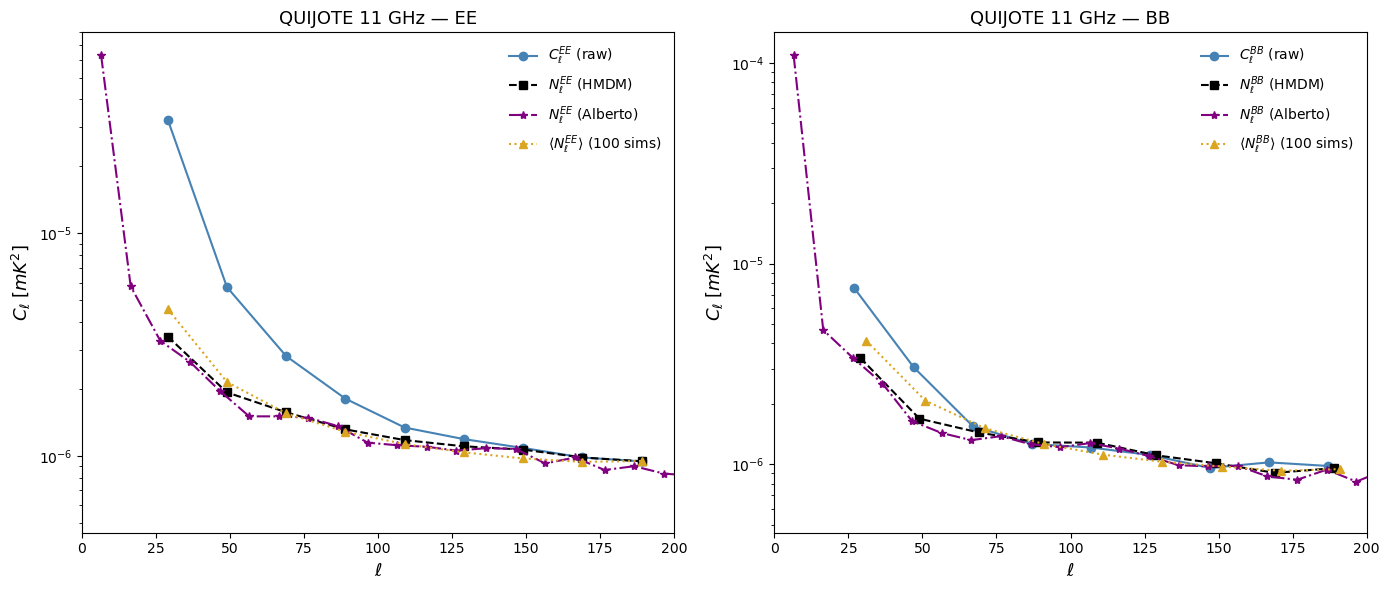

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- EE ----
ax = axes[0]
ax.plot(ell_eff, cl_EE, 'o-', 
        label=r'$C_\ell^{EE}$ (raw)', 
        color='steelblue')

ax.plot(ell_eff, nl_EE, 's--', 
        label=r'$N_\ell^{EE}$ (HMDM)', 
        color='black')

ax.plot(ell_alb, nl_EE_alb, '*-.', 
        label=r'$N_\ell^{EE}$ (Alberto)', 
        color='purple')


ax.plot(ell_eff, mean_noise_EE, '^:', 
        label=r'$\langle N_\ell^{EE} \rangle$ (100 sims)', 
        color='goldenrod')


ax.set_yscale('log')
ax.set_xlabel(r'$\ell$', fontsize=13)
ax.set_ylabel(r'$C_\ell \; [m K^2]$', fontsize=13)
ax.set_title('QUIJOTE 11 GHz — EE', fontsize=13)
ax.legend(frameon=False)
ax.set_xlim(0,200)

# ---- BB ----
ax = axes[1]

ax.plot(ell_eff -2, cl_BB, 'o-', 
        label=r'$C_\ell^{BB}$ (raw)', 
        color='steelblue')

ax.plot(ell_eff, nl_BB, 's--', 
        label=r'$N_\ell^{BB}$ (HMDM)', 
        color='black')

ax.plot(ell_alb, nl_BB_alb, '*-.', 
        label=r'$N_\ell^{BB}$ (Alberto)', 
        color='purple')

ax.plot(ell_eff +2, mean_noise_BB, '^:', 
        label=r'$\langle N_\ell^{BB} \rangle$ (100 sims)', 
        color='goldenrod')

ax.set_yscale('log')
ax.set_xlabel(r'$\ell$', fontsize=13)
ax.set_ylabel(r'$C_\ell \; [m K^2]$', fontsize=13)
ax.set_title('QUIJOTE 11 GHz — BB', fontsize=13)
ax.legend(frameon=False)
ax.set_xlim(0,200)

plt.tight_layout()
plt.show()

fig.savefig('/home/pablo/Desktop/master/tfm/figures/spectra/fitting_range_Cl_Nl_HMDM_mean-noise_alberto.pdf')

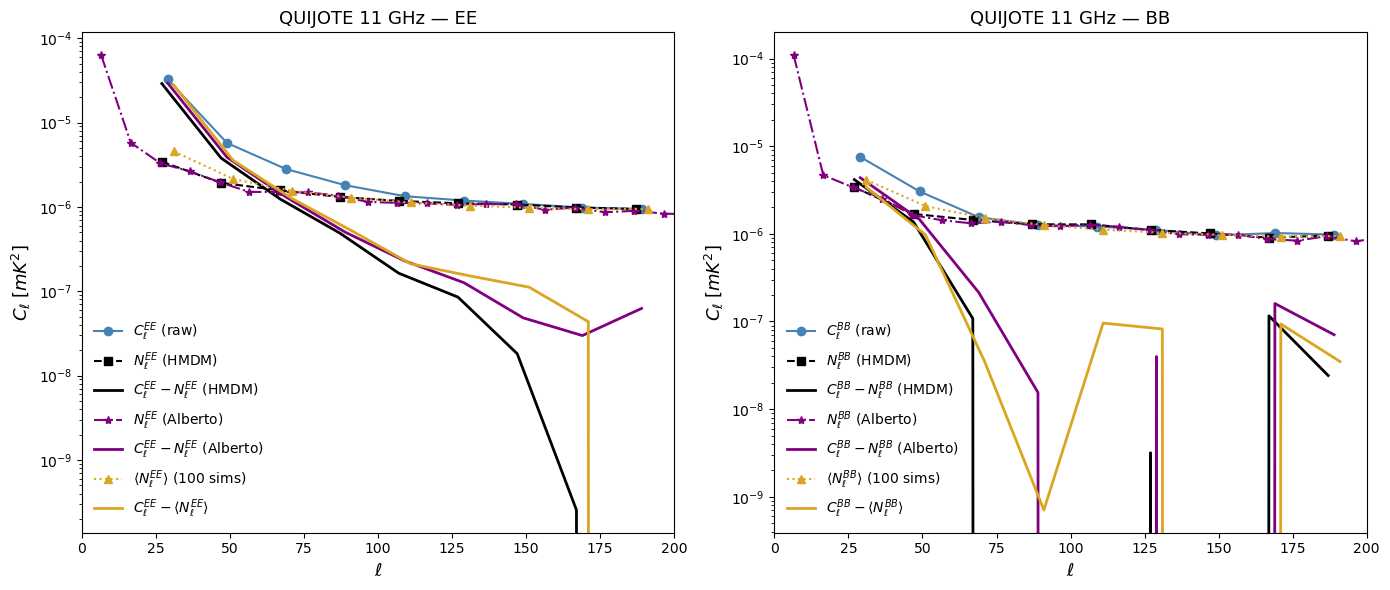

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- EE ----
ax = axes[0]
ax.plot(ell_eff, cl_EE, 'o-', 
        label=r'$C_\ell^{EE}$ (raw)', 
        color='steelblue')

ax.plot(ell_eff -2, nl_EE, 's--', 
        label=r'$N_\ell^{EE}$ (HMDM)', 
        color='black')


ax.plot(ell_eff -2, cl_EE - nl_EE, '-', 
        label=r'$C_\ell^{EE} - N_\ell^{EE}$ (HMDM)', 
        color='k', linewidth=2)


ax.plot(ell_alb, nl_EE_alb, '*-.', 
        label=r'$N_\ell^{EE}$ (Alberto)', 
        color='purple')

ax.plot(ell_eff, cl_EE - nl_EE_alb_interp, '-', 
        label=r'$C_\ell^{EE} - N_\ell^{EE}$ (Alberto)', 
        color='purple', linewidth=2)


ax.plot(ell_eff +2, mean_noise_EE, '^:', 
        label=r'$\langle N_\ell^{EE} \rangle$ (100 sims)', 
        color='goldenrod')

ax.plot(ell_eff +2, cl_EE - mean_noise_EE, '-', 
        label=r'$C_\ell^{EE} - \langle N_\ell^{EE} \rangle$', 
        color='goldenrod', linewidth=2)

ax.set_yscale('log')
ax.set_xlabel(r'$\ell$', fontsize=13)
ax.set_ylabel(r'$C_\ell \; [m K^2]$', fontsize=13)
ax.set_title('QUIJOTE 11 GHz — EE', fontsize=13)
ax.legend(frameon=False)
ax.set_xlim(0,200)

# ---- BB ----
ax = axes[1]

ax.plot(ell_eff, cl_BB, 'o-', 
        label=r'$C_\ell^{BB}$ (raw)', 
        color='steelblue')

ax.plot(ell_eff -2, nl_BB, 's--', 
        label=r'$N_\ell^{BB}$ (HMDM)', 
        color='black')

ax.plot(ell_eff -2, cl_BB - nl_BB, '-', 
        label=r'$C_\ell^{BB} - N_\ell^{BB}$ (HMDM)', 
        color='k', linewidth=2)

ax.plot(ell_alb, nl_BB_alb, '*-.', 
        label=r'$N_\ell^{BB}$ (Alberto)', 
        color='purple')

ax.plot(ell_eff, cl_BB - nl_BB_alb_interp, '-', 
        label=r'$C_\ell^{BB} - N_\ell^{BB}$ (Alberto)', 
        color='purple', linewidth=2)


ax.plot(ell_eff +2, mean_noise_BB, '^:', 
        label=r'$\langle N_\ell^{BB} \rangle$ (100 sims)', 
        color='goldenrod')

ax.plot(ell_eff +2, cl_BB - mean_noise_BB, '-', 
        label=r'$C_\ell^{BB} - \langle N_\ell^{BB} \rangle$', 
        color='goldenrod', linewidth=2)


ax.set_yscale('log')
ax.set_xlabel(r'$\ell$', fontsize=13)
ax.set_ylabel(r'$C_\ell \; [m K^2]$', fontsize=13)
ax.set_title('QUIJOTE 11 GHz — BB', fontsize=13)
ax.legend(frameon=False)
ax.set_xlim(0,200)

plt.tight_layout()
plt.show()

fig.savefig('/home/pablo/Desktop/master/tfm/figures/spectra/fitting_range_Cl_Nl_diff_HMDM_mean-noise_alberto.pdf')

In [30]:
mask_path = '/home/pablo/Downloads/mask_lowdec_satband_galcut10_0mk_apodC2_5.fits'
map_path = '/home/pablo/Downloads/quijote_mfi_skymap_11ghz_512_dr1.fits'
mask = hp.read_map(mask_path)
map = hp.read_map(map_path, field=[0,1,2])

binning_params_lin = {
    'type': 'linear',
    'lmax': lmax,
    'dl': dl,
    'ell1': ell_1,
    'ell2': ell_2,
}

b_lin = functions.create_binning(binning_params_lin)
workspaces_lin = functions.prepare_workspaces(mask, b_lin, nside, lmax=lmax, purify_e=True, purify_b=True)

spectra_lin = functions.compute_all_power_spectra(
    data, ['11'], mask, b_lin,
    use_simulated_maps=use_simulated_maps,
    use_white_noise=use_white_noise,
    noise_realization=1,
    only_noise=False,
    workspaces=workspaces_lin,
    lmax=lmax
)

hmdm_lin = functions.compute_hmdm_power_spectra(
    data, ['11'], mask, b_lin,
    workspaces=workspaces_lin,
    lmax=lmax,
    use_noise=use_noise
)

ell_eff_lin = spectra_lin[0, 0]['ell_eff']
cl_EE_lin   = spectra_lin[0, 0]['EE']
cl_BB_lin   = spectra_lin[0, 0]['BB']
nl_EE_lin   = hmdm_lin[0, 0]['EE']
nl_BB_lin   = hmdm_lin[0, 0]['BB']
mean_noise_EE_lin = np.array(avg_std_noise_spectra['11_11']['EE']['MEAN'])
mean_noise_BB_lin = np.array(avg_std_noise_spectra['11_11']['BB']['MEAN'])


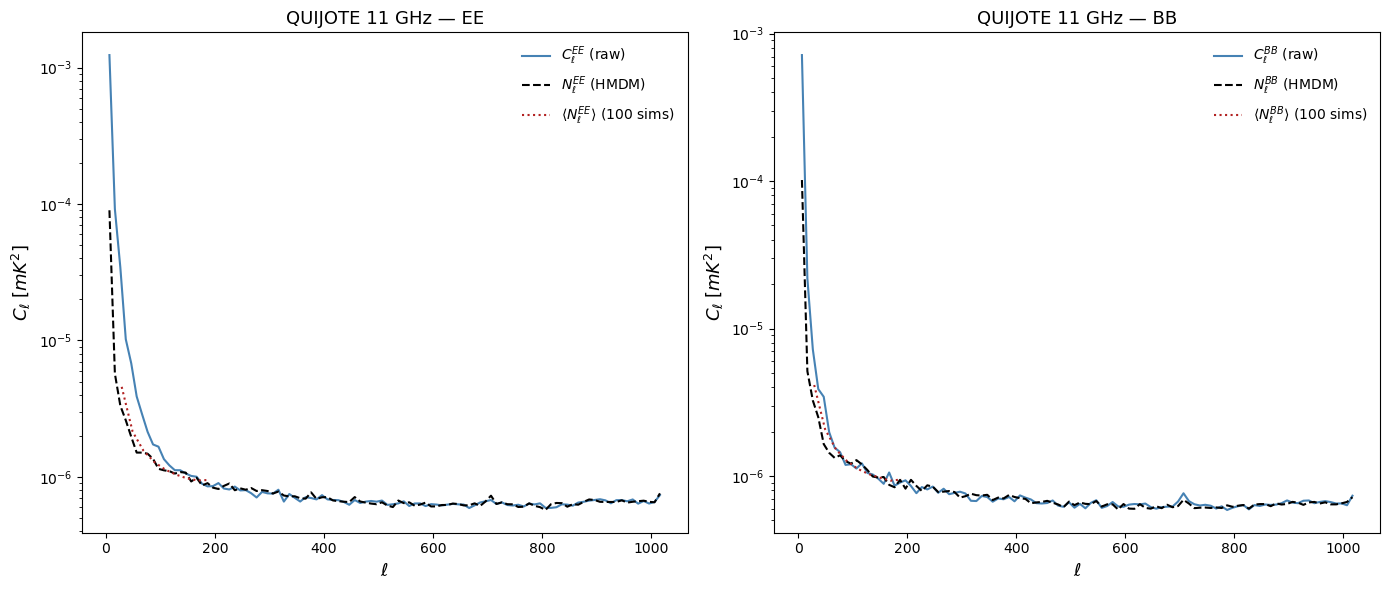

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- EE ----
ax = axes[0]
ax.plot(ell_eff_lin, cl_EE_lin, '-', label=r'$C_\ell^{EE}$ (raw)', color='steelblue')
ax.plot(ell_eff_lin, nl_EE_lin, '--', label=r'$N_\ell^{EE}$ (HMDM)', color='k')
ax.plot(ell_eff, mean_noise_EE_lin, ':', label=r'$\langle N_\ell^{EE} \rangle$ (100 sims)', color='firebrick')
ax.set_yscale('log')
ax.set_xlabel(r'$\ell$', fontsize=13)
ax.set_ylabel(r'$C_\ell \; [m K^2]$', fontsize=13)
ax.set_title('QUIJOTE 11 GHz — EE', fontsize=13)
ax.legend(frameon=False)
# ax.set_xlim(600, 1000)

# ---- BB ----
ax = axes[1]
ax.plot(ell_eff_lin, cl_BB_lin, '-', label=r'$C_\ell^{BB}$ (raw)', color='steelblue')
ax.plot(ell_eff_lin, nl_BB_lin, '--', label=r'$N_\ell^{BB}$ (HMDM)', color='k')
ax.plot(ell_eff, mean_noise_BB_lin, ':', label=r'$\langle N_\ell^{BB} \rangle$ (100 sims)', color='firebrick')
ax.set_yscale('log')
ax.set_xlabel(r'$\ell$', fontsize=13)
ax.set_ylabel(r'$C_\ell \; [m K^2]$', fontsize=13)
ax.set_title('QUIJOTE 11 GHz — BB', fontsize=13)
ax.legend(frameon=False)
# ax.set_xlim(600, 1000)

plt.tight_layout()
plt.show()

fig.savefig('/home/pablo/Desktop/master/tfm/figures/spectra/full_Cl_Nl_HMDM_mean-noise.pdf')

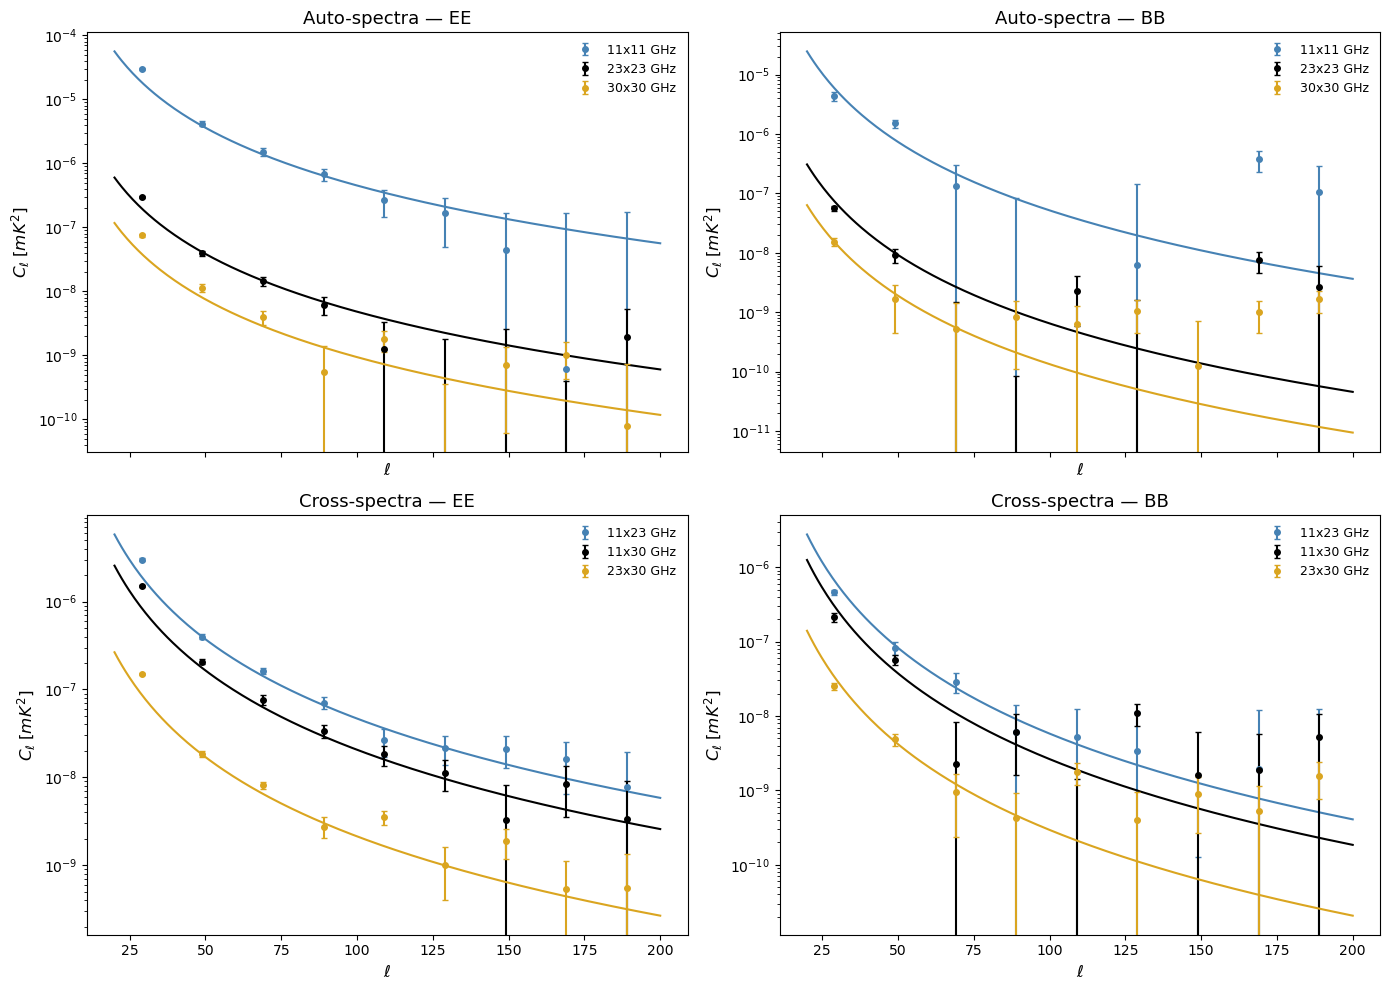

In [13]:

import matplotlib.colors as mcolors

# ------------------------------
# Synchrotron model parameters
# ------------------------------
# EE mode
A_s_EE     = 9.423e-9
alpha_s_EE = -2.997
beta_s_EE  = -3.076

# BB mode
A_s_BB     = 1.525e-9
alpha_s_BB = -3.827
beta_s_BB  = -2.969

# ====================

# # EE mode
# A_s_EE     = 9.408e-9
# alpha_s_EE = -2.890
# beta_s_EE  = -3.135

# # BB mode
# A_s_BB     = 2.050e-9
# alpha_s_BB = -3.207
# beta_s_BB  = -2.723

freq_ref = 23.0
ell_ref  = 80.0

auto_bands = ['11', '23', '30']

cross_pairs = [
    ('11', '23'),
    ('11', '30'),
    ('23', '30'),
    # ('11', '33'),
    # ('23', '33'),
    # ('30', '33'),
]

band_colors = {
    '11': 'steelblue',
    '23': 'k',
    '30': 'goldenrod',
    '33': 'purple',
}

# Colors for cross pairs — same order as band_colors
cross_colors = list(band_colors.values())

plot_freqs   = {b: float(b) for b in band_colors}
spectra_plot = functions.read_corrected_cls(path_corrected_spectra, band_list)

def sync_model(ell_arr, f1, f2, A_s, alpha_s, beta_s):
    return (A_s
            * (ell_arr / ell_ref) ** alpha_s
            * (f1 / freq_ref) ** beta_s
            * (f2 / freq_ref) ** beta_s)

mode_params = {
    'EE': (A_s_EE, alpha_s_EE, beta_s_EE),
    'BB': (A_s_BB, alpha_s_BB, beta_s_BB),
}

ell_fine = np.linspace(20, 200, 300)

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
ax_EE_auto, ax_BB_auto   = axes[0]
ax_EE_cross, ax_BB_cross = axes[1]

# ---- AUTO spectra ----
for b in auto_bands:
    key = f'{b}_{b}'
    if key not in spectra_plot:
        continue
    ell_eff = spectra_plot[key]['ell_eff']
    f = plot_freqs[b]
    col = band_colors[b]

    for ax, mode in [(ax_EE_auto, 'EE'), (ax_BB_auto, 'BB')]:
        A_s, alpha_s, beta_s = mode_params[mode]
        cl  = spectra_plot[key][mode]['SPECTRUM']
        err = spectra_plot[key][mode]['ERROR']
        ax.errorbar(ell_eff, cl, yerr=err, fmt='o', color=col,
                    label=f'{b}x{b} GHz', capsize=2, ms=4)
        ax.plot(ell_fine, sync_model(ell_fine, f, f, A_s, alpha_s, beta_s),
                '-', color=col, lw=1.5)

ax_EE_auto.set_title('Auto-spectra — EE', fontsize=13)
ax_BB_auto.set_title('Auto-spectra — BB', fontsize=13)

# ---- CROSS spectra ----
for i, (b1, b2) in enumerate(cross_pairs):
    key = f'{b1}_{b2}'
    if key not in spectra_plot:
        key = f'{b2}_{b1}'
    if key not in spectra_plot:
        print(f'Warning: pair {b1}x{b2} not found in spectra, skipping.')
        continue
    ell_eff = spectra_plot[key]['ell_eff']
    f1, f2  = plot_freqs[b1], plot_freqs[b2]
    col     = cross_colors[i % len(cross_colors)]
    label   = f'{b1}x{b2} GHz'

    for ax, mode in [(ax_EE_cross, 'EE'), (ax_BB_cross, 'BB')]:
        A_s, alpha_s, beta_s = mode_params[mode]
        cl  = spectra_plot[key][mode]['SPECTRUM']
        err = spectra_plot[key][mode]['ERROR']
        ax.errorbar(ell_eff, cl, yerr=err, fmt='o', color=col,
                    label=label, capsize=2, ms=4)
        ax.plot(ell_fine, sync_model(ell_fine, f1, f2, A_s, alpha_s, beta_s),
                '-', color=col, lw=1.5)

ax_EE_cross.set_title('Cross-spectra — EE', fontsize=13)
ax_BB_cross.set_title('Cross-spectra — BB', fontsize=13)

# ---- Shared formatting ----
for ax in axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$', fontsize=12)
    ax.set_ylabel(r'$C_\ell \; [m K^2]$', fontsize=12)
    ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

fig.savefig('/home/pablo/Desktop/master/tfm/figures/spectra/spectra_model_fit.pdf')

In [12]:
import matplotlib as mpl
import numpy as np

def save_figure_transparent_white(fig, out_path, dpi=300):
    """
    Save `fig` as a transparent PNG and convert black elements to white.
    - fig: matplotlib.figure.Figure
    - out_path: output PNG path
    """
    def is_black_color(c):
        # Accept color string 'k'/'black', hex '#000000', or RGBA tuple close to black
        try:
            # If it's a string like 'k' or 'black' or a hex string
            if isinstance(c, str):
                return c.lower() in ('k', 'black', '#000000')
            # If it's a tuple/list/ndarray RGBA-ish
            if hasattr(c, '__len__'):
                # Convert to rgba tuple of floats
                rgba = mpl.colors.to_rgba(c)
                # consider black if RGB components all near zero (alpha ignored)
                return (rgba[0] < 1e-6) and (rgba[1] < 1e-6) and (rgba[2] < 1e-6)
        except Exception:
            pass
        return False

    # Make figure background transparent
    try:
        fig.patch.set_alpha(0.0)
    except Exception:
        pass

    # Iterate axes and change colors for black elements -> white
    for ax in fig.axes:
        # Transparent axes background
        try:
            ax.set_facecolor('none')
        except Exception:
            pass

        # Titles and axis labels to white if they are black
        try:
            if is_black_color(ax.title.get_color()):
                ax.title.set_color('white')
        except Exception:
            pass
        try:
            if is_black_color(ax.xaxis.label.get_color()):
                ax.xaxis.label.set_color('white')
            if is_black_color(ax.yaxis.label.get_color()):
                ax.yaxis.label.set_color('white')
        except Exception:
            pass

        # Tick labels and tick lines to white
        try:
            ax.tick_params(colors='white')
            # Also change ticklabel text objects specifically if needed
            for lbl in ax.get_xticklabels() + ax.get_yticklabels():
                try:
                    if is_black_color(lbl.get_color()):
                        lbl.set_color('white')
                except Exception:
                    pass
        except Exception:
            pass

        # Spines (border) to white if black
        try:
            for spine in ax.spines.values():
                try:
                    if is_black_color(spine.get_edgecolor()):
                        spine.set_edgecolor('white')
                except Exception:
                    # spine.get_edgecolor may return RGBA; check via to_rgba
                    try:
                        ec = spine.get_edgecolor()
                        if is_black_color(ec):
                            spine.set_edgecolor('white')
                    except Exception:
                        pass
        except Exception:
            pass

        # Legend text and frame
        try:
            leg = ax.get_legend()
            if leg is not None:
                for text in leg.get_texts():
                    try:
                        if is_black_color(text.get_color()):
                            text.set_color('white')
                    except Exception:
                        pass
                try:
                    # make legend frame transparent but edge in white if black
                    frame = leg.get_frame()
                    frame.set_alpha(0.0)
                    if is_black_color(frame.get_edgecolor()):
                        frame.set_edgecolor('white')
                except Exception:
                    pass
        except Exception:
            pass

        # Lines: convert explicitly-black lines to white (keeps colored lines intact)
        try:
            for line in ax.get_lines():
                try:
                    c = line.get_color()
                    if is_black_color(c):
                        line.set_color('white')
                except Exception:
                    pass
        except Exception:
            pass

        # Collections (e.g., errorbars, scatter): attempt to recolor edge/face colors if black
        try:
            for coll in ax.collections:
                try:
                    # PathCollection (scatter)
                    fc = coll.get_facecolors()
                    if fc is not None and len(fc):
                        # fc may be an array Nx4; check first color
                        first = fc[0]
                        if is_black_color(tuple(first)):
                            # set to white (keep alpha)
                            new = np.array(fc)
                            new[:, :3] = 1.0
                            coll.set_facecolors(new)
                    ec = coll.get_edgecolors()
                    if ec is not None and len(ec):
                        first_e = ec[0]
                        if is_black_color(tuple(first_e)):
                            new_e = np.array(ec)
                            new_e[:, :3] = 1.0
                            coll.set_edgecolors(new_e)
                except Exception:
                    # LineCollection or other: try a generic to_rgba check on default color
                    try:
                        c = getattr(coll, 'get_color', None)
                        if callable(c):
                            col = coll.get_color()
                            if is_black_color(col):
                                coll.set_color('white')
                    except Exception:
                        pass
        except Exception:
            pass

    # Also change any Text objects on the figure that are black
    try:
        for text in fig.findobj(mpl.text.Text):
            try:
                if is_black_color(text.get_color()):
                    text.set_color('white')
            except Exception:
                pass
    except Exception:
        pass

    # Finally save transparent PNG
    fig.savefig(out_path, transparent=True, facecolor='none', bbox_inches='tight', dpi=dpi)
    print('Saved transparent PNG to', out_path)


# Example usage (run where `fig` exists)
png_out = '/home/pablo/Desktop/master/tfm/figures/spectra/spectra_model_fit_transparent.png'
save_figure_transparent_white(fig, png_out, dpi=300)

Saved transparent PNG to /home/pablo/Desktop/master/tfm/figures/spectra/spectra_model_fit_transparent.png
